# 06 · PJM Energy Demand — Anomaly & Event Detection

## Part 6 — Anomaly & Event Detection

Real grids care intensely about the *unusual*: the heat-wave hour that sets a record, the holiday that
empties the offices, the slow structural drift that reshapes planning. This part finds all three:
**point anomalies** (via a calendar-climatology residual), **systematic events** (holidays), and
**structural breaks** (via change-point detection). A nice sanity check falls out — the anomaly
detector *rediscovers the public-holiday calendar on its own*.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import data, eda
eda.set_style()
pd.set_option("display.width", 130, "display.max_columns", 40)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

import ruptures as rpt
from statsmodels.tsa.seasonal import STL
d = data.clean_primary(); s = d.load_mw

setup ok | numpy 2.1.3 | pandas 2.3.3


### 1. A calendar-climatology baseline

To spot the *unexpected*, first model the *expected*. We compute the average demand for each
**(month, weekend?, hour)** cell — a simple climatology that captures the seasonal + weekly + daily
structure — and take the **residual** (actual − expected). Standardised, the residual is an anomaly
score: how many σ a given hour deviates from its calendar norm.

residual std: 3397 MW | anomalies |z|>4: 334 hours (0.23% of all hours)


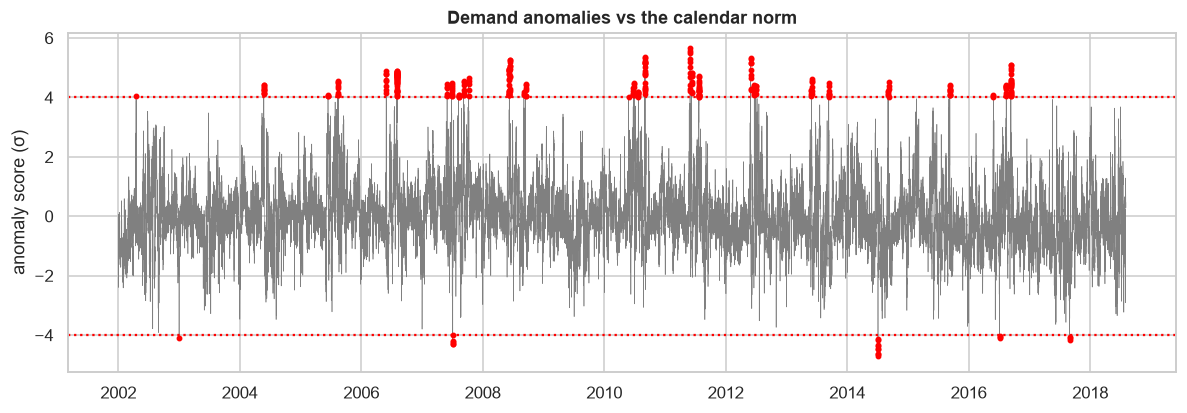

In [2]:
expected = s.groupby([d.month, d.is_weekend, d.hour]).transform("mean")
resid = s - expected
z = resid / resid.std()
print("residual std: %.0f MW | anomalies |z|>4: %d hours (%.2f%% of all hours)" % (resid.std(), (z.abs()>4).sum(), 100*(z.abs()>4).mean()))
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(s.index, z, color="grey", lw=.4); ax.axhline(4, color="red", ls=":"); ax.axhline(-4, color="red", ls=":")
ax.scatter(z[z.abs()>4].index, z[z.abs()>4], s=8, color="red", zorder=3)
ax.set_ylabel("anomaly score (σ)"); ax.set_title("Demand anomalies vs the calendar norm")
eda.savefig(fig, "p6_anomalies.png"); plt.show()

### 2. What the extremes are — heat waves & holidays

The largest **positive** anomalies are **off-season heat waves** — hot spells the calendar doesn't
expect (a 53 GW afternoon on **31-May-2011**, weeks before summer). The largest **negative** anomalies
land on **public holidays** — and since our climatology *doesn't know about holidays*, the detector
flags **4-July-2014** purely from the data. Anomaly detection independently recovered the holiday
calendar — a satisfying validation.

In [3]:
print("TOP positive anomalies (unexpected HIGH — heat waves):")
for t, v in z.nlargest(4).items(): print("   %s  %+.1f σ   %.0f MW" % (t, v, s[t]))
print("\nTOP negative anomalies (unexpected LOW — holidays):")
for t, v in z.nsmallest(4).items(): print("   %s  %+.1f σ   %.0f MW   (%s)" % (t, v, s[t], t.strftime("%a %d-%b")))
print("\nholiday mean anomaly: %+.2f σ  vs non-holiday %+.2f σ  -> holidays run systematically low" %
      (z[d.is_holiday==1].mean(), z[d.is_holiday==0].mean()))

TOP positive anomalies (unexpected HIGH — heat waves):
   2011-05-31 17:00:00  +5.7 σ   53057 MW
   2011-05-31 16:00:00  +5.5 σ   52529 MW
   2011-05-31 18:00:00  +5.5 σ   52451 MW
   2010-09-02 17:00:00  +5.3 σ   56336 MW

TOP negative anomalies (unexpected LOW — holidays):
   2014-07-04 17:00:00  -4.7 σ   31469 MW   (Fri 04-Jul)
   2014-07-04 18:00:00  -4.7 σ   31431 MW   (Fri 04-Jul)
   2014-07-04 16:00:00  -4.6 σ   31493 MW   (Fri 04-Jul)
   2014-07-04 19:00:00  -4.5 σ   30857 MW   (Fri 04-Jul)

holiday mean anomaly: -0.52 σ  vs non-holiday +0.02 σ  -> holidays run systematically low


### 3. When do anomalies cluster?

Counting extreme hours by month shows anomalies are **summer-heavy** — the season of volatile,
weather-driven demand (heat waves), consistent with Part 2's finding that summer is the operationally
hard season. Winter contributes a secondary cluster (cold snaps + holiday season).

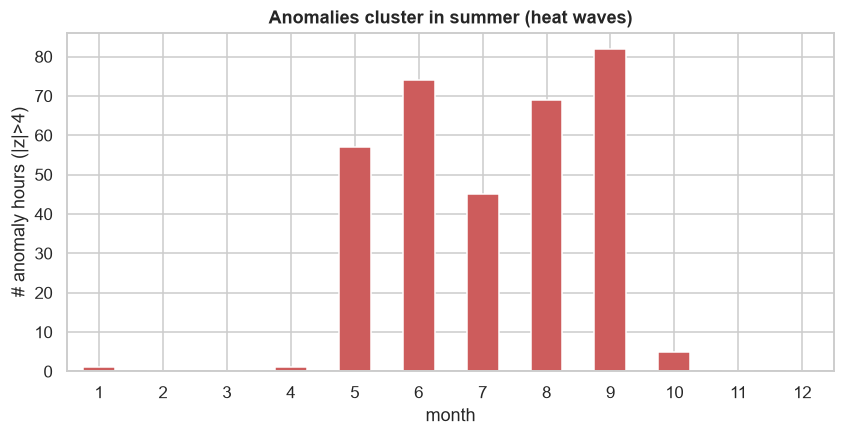

In [4]:
anom_months = z[z.abs()>4].index.month
fig, ax = plt.subplots(figsize=(9, 4))
pd.Series(anom_months).value_counts().reindex(range(1,13), fill_value=0).plot.bar(ax=ax, color="indianred", rot=0)
ax.set_xlabel("month"); ax.set_ylabel("# anomaly hours (|z|>4)"); ax.set_title("Anomalies cluster in summer (heat waves)")
eda.savefig(fig, "p6_anom_month.png"); plt.show()

### 4. Structural breaks — change-point detection

Point anomalies are single hours; a **change-point** is a lasting shift in the *level*. We extract the
slow **trend** (STL on the daily mean) and ask change-point detection (`ruptures`, optimal
segmentation) for the few dates where the trend steps to a new regime. The breaks (~2004, 2011, 2015)
mark a rise to a mid-2000s plateau, then **two step-downs** into the post-recession **efficiency era** —
the structural story behind Part 1's declining trend.

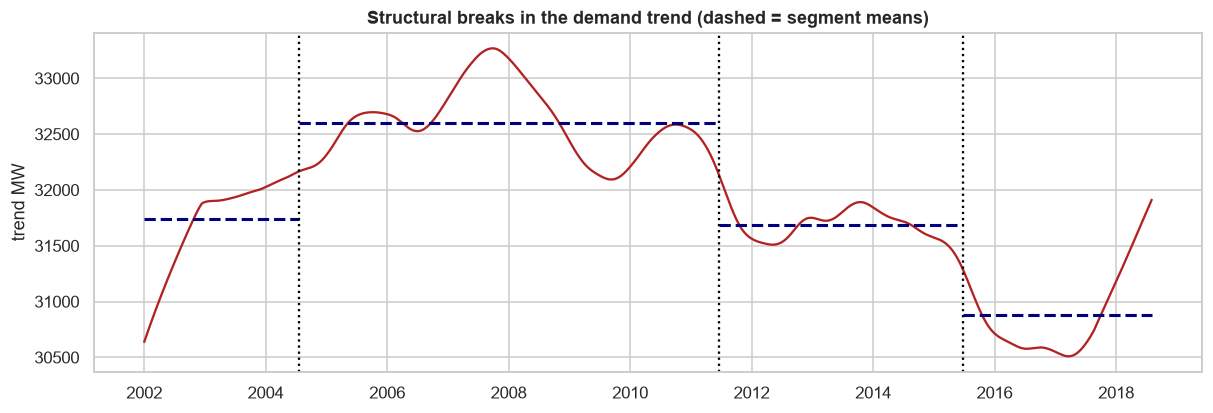

breaks: ['2004-07-18', '2011-06-17', '2015-06-26']
segment means: [31735, 32597, 31686, 30876] MW


In [5]:
daily = s.resample("D").mean()
trend = STL(daily, period=365, robust=True).fit().trend
bkps = rpt.Dynp(model="l2", min_size=180).fit(trend.values).predict(n_bkps=3)
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(trend.index, trend, color="firebrick", lw=1.5)
segs = [0] + bkps
for i in range(len(segs)-1):
    seg = trend.iloc[segs[i]:segs[i+1]]
    ax.hlines(seg.mean(), seg.index[0], seg.index[-1], color="navy", lw=2, ls="--")
    if i < len(segs)-2: ax.axvline(seg.index[-1], color="black", ls=":")
ax.set_ylabel("trend MW"); ax.set_title("Structural breaks in the demand trend (dashed = segment means)")
eda.savefig(fig, "p6_changepoints.png"); plt.show()
print("breaks:", [str(trend.index[b-1].date()) for b in bkps[:-1]])
print("segment means:", [round(trend.iloc[segs[i]:segs[i+1]].mean()) for i in range(len(segs)-1)], "MW")

### Takeaways

- A **calendar-climatology residual** is a cheap, interpretable anomaly detector: ~0.2% of hours
  exceed 4σ.
- The extremes decompose cleanly: **positive = off-season heat waves**, **negative = holidays** — and
  the detector **rediscovered the holiday calendar** unaided (July 4th as the top negative anomaly).
- Anomalies **cluster in summer** (weather-driven volatility).
- **Change-point detection** on the trend finds ~2004/2011/2015 breaks — a rise to a plateau then two
  **step-downs into the efficiency era**, the structure behind the long-run decline.

**Next — Part 7 (Univariate forecasting):** put the structure to work — baselines, MSTL-ETS, harmonic
regression and AutoARIMA for day-ahead demand, scored honestly against seasonal-naive.